<a href="https://colab.research.google.com/github/pw4ch7re3/house-price-regressor/blob/Lim-Jaeyun/experiments%20/%20dt_mlp_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# DT, MLP 모델의 하이퍼파라미터 변경하면서 성능 변화 그래프 제작


# 전처리 및 함수


In [10]:
import os
import sys
import random
import copy
import time

path = os.path.dirname(os.getcwd())
if path not in sys.path:
    sys.path.insert(0, path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from data.dataload import load_df, split_X_y
from models import TrainConfig
from models.decision_tree import DecisionTreeConfig, DecisionTree
from models.mlp import MLPConfig, MLP
from metrics.mse import rmse
from metrics.r2_score import r2_score

In [11]:
SEED = 42
TARGET = "price"
DATA_PATH = os.path.join(path, "data", "processed", "usa_housing_dataset_processed.csv")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(SEED)

df = load_df(DATA_PATH)
print("데이터 크기:", df.shape)
display(df.head())

X, y = split_X_y(df, TARGET)

# 혹시 object/categorical 컬럼이 있으면 one-hot 처리
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if len(non_numeric_cols) > 0:
    print("원-핫 인코딩 대상 컬럼:", non_numeric_cols)
    X = pd.get_dummies(X, columns=non_numeric_cols, drop_first=True)

# train/test 8:2, 그리고 train에서 val 분리
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,  # 전체 기준 train 60%, val 20%, test 20%
    random_state=SEED,
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

데이터 크기: (4086, 19)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,street,city,statezip,x,y,z,has_basement,was_renovated,age
0,280.597015,3.0,2.00,1340,1384,3.0,0,0,3,1340,3908,34,47,-0.360144,-0.568590,0.739596,0,0,6
1,225.988701,4.0,3.25,3540,159430,2.0,0,0,3,3540,2454,7,10,-0.356115,-0.572148,0.738802,0,0,7
2,307.962586,5.0,6.50,7270,130017,2.0,0,0,3,6420,3460,15,17,-0.357555,-0.572634,0.737730,1,0,4
3,324.649299,3.0,2.25,998,904,2.0,0,0,3,798,3710,34,56,-0.360299,-0.568478,0.739607,1,0,7
4,179.705882,5.0,2.75,3060,7015,1.0,0,0,5,1600,174,34,65,-0.361685,-0.570538,0.737340,1,0,35


X_train: (2451, 18)
X_val: (817, 18)
X_test: (818, 18)


In [12]:
# 결측치 처리
imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)

X_val_imp = pd.DataFrame(
    imputer.transform(X_val), columns=X_val.columns, index=X_val.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test), columns=X_test.columns, index=X_test.index
)

# DT용 데이터
X_train_dt = X_train_imp
X_val_dt = X_val_imp
X_test_dt = X_test_imp

# MLP용 데이터: StandardScaler 적용
scaler = StandardScaler()

X_train_mlp = pd.DataFrame(
    scaler.fit_transform(X_train_imp),
    columns=X_train_imp.columns,
    index=X_train_imp.index,
)

X_val_mlp = pd.DataFrame(
    scaler.transform(X_val_imp), columns=X_val_imp.columns, index=X_val_imp.index
)

X_test_mlp = pd.DataFrame(
    scaler.transform(X_test_imp), columns=X_test_imp.columns, index=X_test_imp.index
)

print("전처리 완료")
print("MLP input_dim:", X_train_mlp.shape[1])

전처리 완료
MLP input_dim: 18


In [13]:
def evaluate_regression(model, X_data, y_true):
    y_pred = model.predict(X_data)
    return {"rmse": float(rmse(y_true, y_pred)), "r2": float(r2_score(y_true, y_pred))}


def add_eval_results(
    row,
    model,
    X_train_data,
    y_train_data,
    X_val_data,
    y_val_data,
    X_test_data,
    y_test_data,
):
    train_metrics = evaluate_regression(model, X_train_data, y_train_data)
    val_metrics = evaluate_regression(model, X_val_data, y_val_data)
    test_metrics = evaluate_regression(model, X_test_data, y_test_data)

    row["train_rmse"] = train_metrics["rmse"]
    row["val_rmse"] = val_metrics["rmse"]
    row["test_rmse"] = test_metrics["rmse"]

    row["train_r2"] = train_metrics["r2"]
    row["val_r2"] = val_metrics["r2"]
    row["test_r2"] = test_metrics["r2"]

    return row


def make_label(value):
    if isinstance(value, list):
        return "-".join(map(str, value))
    if isinstance(value, type):
        return value.__name__
    return str(value)


def plot_hparam_result(result_df, x_col, title_prefix):
    labels = result_df[x_col].apply(make_label).tolist()
    x_pos = np.arange(len(labels))

    # RMSE 그래프
    plt.figure(figsize=(9, 5))
    plt.plot(x_pos, result_df["train_rmse"], marker="o", label="Train RMSE")
    plt.plot(x_pos, result_df["val_rmse"], marker="o", label="Validation RMSE")
    plt.plot(x_pos, result_df["test_rmse"], marker="o", label="Test RMSE")
    plt.xticks(x_pos, labels, rotation=45)
    plt.xlabel(x_col)
    plt.ylabel("RMSE")
    plt.title(f"{title_prefix} - RMSE 변화")
    plt.legend()
    plt.grid(True)
    plt.show()

    # R2 그래프
    plt.figure(figsize=(9, 5))
    plt.plot(x_pos, result_df["train_r2"], marker="o", label="Train R2")
    plt.plot(x_pos, result_df["val_r2"], marker="o", label="Validation R2")
    plt.plot(x_pos, result_df["test_r2"], marker="o", label="Test R2")
    plt.xticks(x_pos, labels, rotation=45)
    plt.xlabel(x_col)
    plt.ylabel("R2")
    plt.title(f"{title_prefix} - R2 변화")
    plt.legend()
    plt.grid(True)
    plt.show()


def show_best_by_validation(result_df, model_name):
    best_rmse_row = result_df.loc[result_df["val_rmse"].idxmin()]
    best_r2_row = result_df.loc[result_df["val_r2"].idxmax()]

    print(f"[{model_name}] Validation RMSE 기준 best")
    display(best_rmse_row.to_frame().T)

    print(f"[{model_name}] Validation R2 기준 best")
    display(best_r2_row.to_frame().T)

# DT


In [14]:
def run_dt_sweep(param_name, values, base_params=None):
    if base_params is None:
        base_params = {
            "max_depth": 6,
            "min_samples_split": 2,
            "min_samples_leaf": 1,
            "max_features": None,
        }

    results = []

    for value in values:
        params = copy.deepcopy(base_params)
        params[param_name] = value

        set_seed(SEED)

        config = DecisionTreeConfig(
            model="dt",
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"],
        )

        model = DecisionTree(config)

        train_config = TrainConfig(
            X=X_train_dt,
            y=y_train,
            epochs=0,  # DT에서는 사용 안 함
            lr=0.0,  # DT에서는 사용 안 함
            batch_size=None,
            verbose=False,
        )

        start_time = time.time()
        model.fit(train_config)
        elapsed = time.time() - start_time

        row = {
            "model": "dt",
            "changed_param": param_name,
            param_name: value,
            "max_depth": params["max_depth"],
            "min_samples_split": params["min_samples_split"],
            "min_samples_leaf": params["min_samples_leaf"],
            "max_features": params["max_features"],
            "train_time_sec": elapsed,
        }

        row = add_eval_results(
            row, model, X_train_dt, y_train, X_val_dt, y_val, X_test_dt, y_test
        )

        results.append(row)

    return pd.DataFrame(results)

,model,changed_param,max_depth,min_samples_split,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,dt,max_depth,2.0,2,1,None,0.004248,83.833119,81.734096,80.529981,0.382937,0.415559,0.413471
1,dt,max_depth,3.0,2,1,None,0.005677,78.944751,78.847378,76.144683,0.452801,0.456113,0.475611
2,dt,max_depth,4.0,2,1,None,0.007160,73.812458,75.639469,73.232517,0.521637,0.499469,0.514954
3,dt,max_depth,5.0,2,1,None,0.007596,68.958211,74.290391,72.501416,0.582487,0.517164,0.524591
4,dt,max_depth,6.0,2,1,None,0.008210,63.817649,69.894712,68.816724,0.642414,0.572611,0.571686
5,dt,max_depth,8.0,2,1,None,0.009748,54.543282,68.816527,73.928159,0.738795,0.585695,0.505696
6,dt,max_depth,10.0,2,1,None,0.012044,44.837875,72.563834,73.666649,0.823482,0.539346,0.509187
7,dt,max_depth,12.0,2,1,None,0.014056,34.138551,80.032773,80.057619,0.897673,0.439636,0.420331
8,dt,max_depth,NaN,2,1,None,0.019818,0.000000,84.470760,84.567193,1.000000,0.375766,0.353187


[DT max_depth] Validation RMSE 기준 best


,model,changed_param,max_depth,min_samples_split,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
5,dt,max_depth,8.0,2,1,None,0.009748,54.543282,68.816527,73.928159,0.738795,0.585695,0.505696


[DT max_depth] Validation R2 기준 best


,model,changed_param,max_depth,min_samples_split,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
5,dt,max_depth,8.0,2,1,None,0.009748,54.543282,68.816527,73.928159,0.738795,0.585695,0.505696


/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


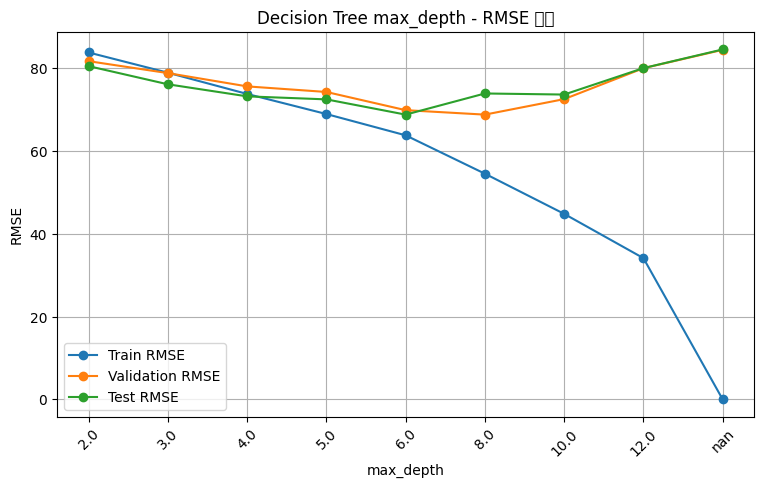

/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


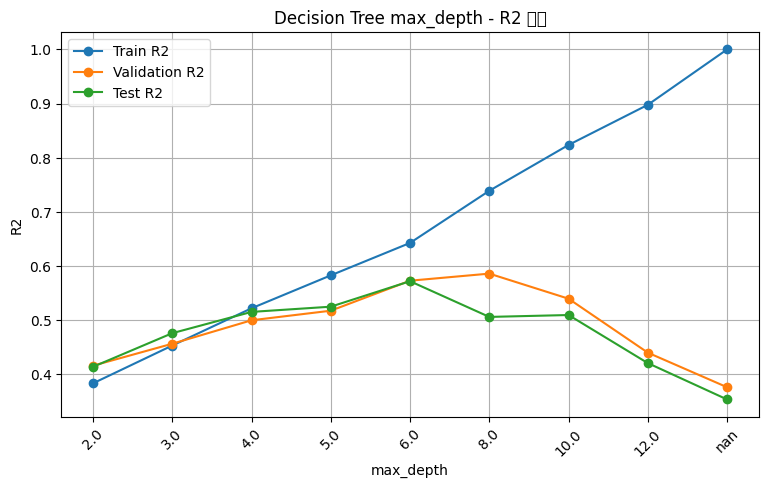

In [15]:
dt_max_depth_values = [2, 3, 4, 5, 6, 8, 10, 12, None]

dt_max_depth_result = run_dt_sweep(
    param_name="max_depth",
    values=dt_max_depth_values,
    base_params={
        "max_depth": 6,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": None,
    },
)

display(dt_max_depth_result)
show_best_by_validation(dt_max_depth_result, "DT max_depth")
plot_hparam_result(dt_max_depth_result, "max_depth", "Decision Tree max_depth")

,model,changed_param,min_samples_leaf,max_depth,min_samples_split,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,dt,min_samples_leaf,1,6,2,None,0.009052,63.817649,69.894712,68.816724,0.642414,0.572611,0.571686
1,dt,min_samples_leaf,2,6,2,None,0.009514,63.724511,70.007457,70.412262,0.643457,0.571231,0.551594
2,dt,min_samples_leaf,4,6,2,None,0.011361,64.705177,72.106522,69.340858,0.632399,0.545134,0.565136
3,dt,min_samples_leaf,8,6,2,None,0.010103,65.338458,69.998704,69.240236,0.625168,0.571339,0.566398
4,dt,min_samples_leaf,16,6,2,None,0.008208,66.561101,68.068913,68.749369,0.611009,0.594648,0.572524
5,dt,min_samples_leaf,32,6,2,None,0.007751,67.607540,68.367168,67.551279,0.598682,0.591088,0.587293


[DT min_samples_leaf] Validation RMSE 기준 best


,model,changed_param,min_samples_leaf,max_depth,min_samples_split,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
4,dt,min_samples_leaf,16,6,2,None,0.008208,66.561101,68.068913,68.749369,0.611009,0.594648,0.572524


[DT min_samples_leaf] Validation R2 기준 best


,model,changed_param,min_samples_leaf,max_depth,min_samples_split,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
4,dt,min_samples_leaf,16,6,2,None,0.008208,66.561101,68.068913,68.749369,0.611009,0.594648,0.572524


/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


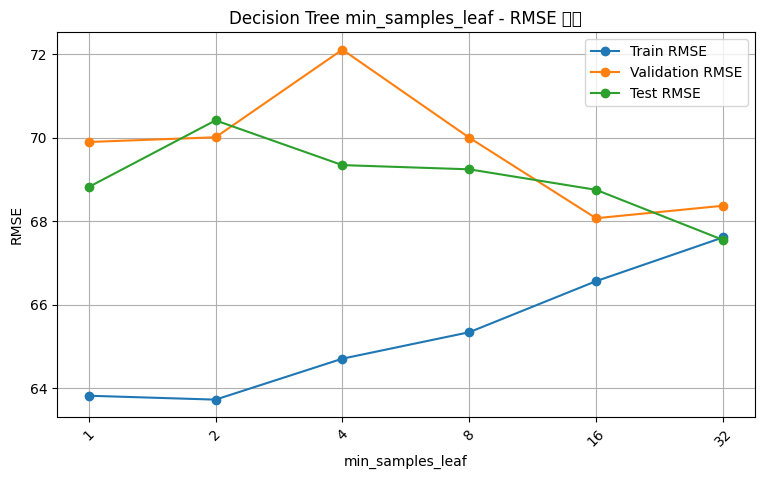

/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


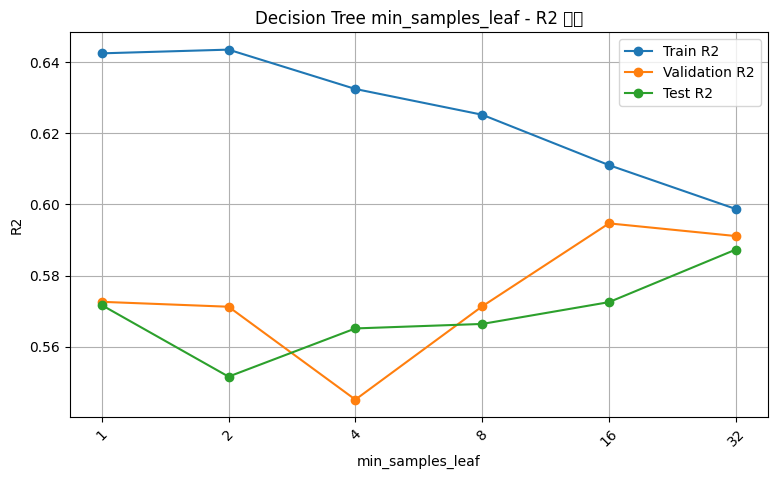

In [16]:
dt_min_samples_leaf_values = [1, 2, 4, 8, 16, 32]

dt_min_leaf_result = run_dt_sweep(
    param_name="min_samples_leaf",
    values=dt_min_samples_leaf_values,
    base_params={
        "max_depth": 6,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": None,
    },
)

display(dt_min_leaf_result)
show_best_by_validation(dt_min_leaf_result, "DT min_samples_leaf")
plot_hparam_result(
    dt_min_leaf_result, "min_samples_leaf", "Decision Tree min_samples_leaf"
)

,model,changed_param,min_samples_split,max_depth,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,dt,min_samples_split,2,6,1,None,0.009682,63.817649,69.894712,68.816724,0.642414,0.572611,0.571686
1,dt,min_samples_split,4,6,1,None,0.013246,63.890034,69.213697,68.835912,0.641603,0.580899,0.571447
2,dt,min_samples_split,8,6,1,None,0.008890,64.191561,68.679133,68.503979,0.638212,0.587348,0.575570
3,dt,min_samples_split,16,6,1,None,0.010753,64.442290,68.736221,68.140423,0.635380,0.586662,0.580063
4,dt,min_samples_split,32,6,1,None,0.008716,65.287875,68.064584,68.370940,0.625748,0.594700,0.577217
5,dt,min_samples_split,64,6,1,None,0.008257,66.239639,67.225569,68.333582,0.614757,0.604630,0.577679


[DT min_samples_split] Validation RMSE 기준 best


,model,changed_param,min_samples_split,max_depth,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
5,dt,min_samples_split,64,6,1,None,0.008257,66.239639,67.225569,68.333582,0.614757,0.60463,0.577679


[DT min_samples_split] Validation R2 기준 best


,model,changed_param,min_samples_split,max_depth,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
5,dt,min_samples_split,64,6,1,None,0.008257,66.239639,67.225569,68.333582,0.614757,0.60463,0.577679


/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


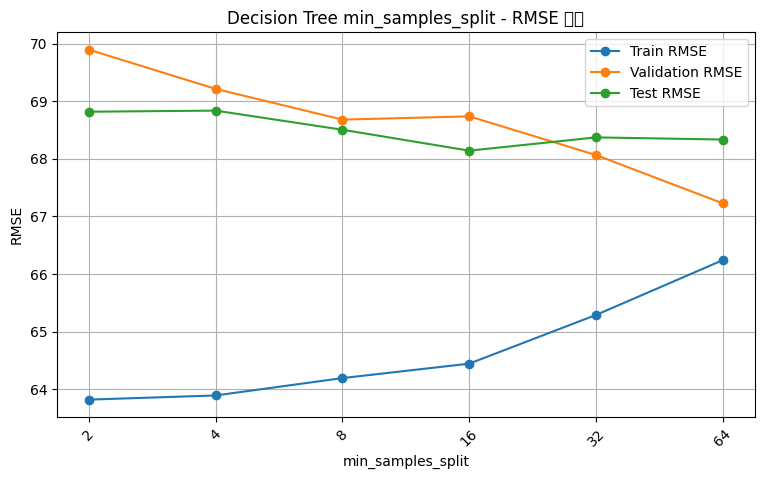

/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


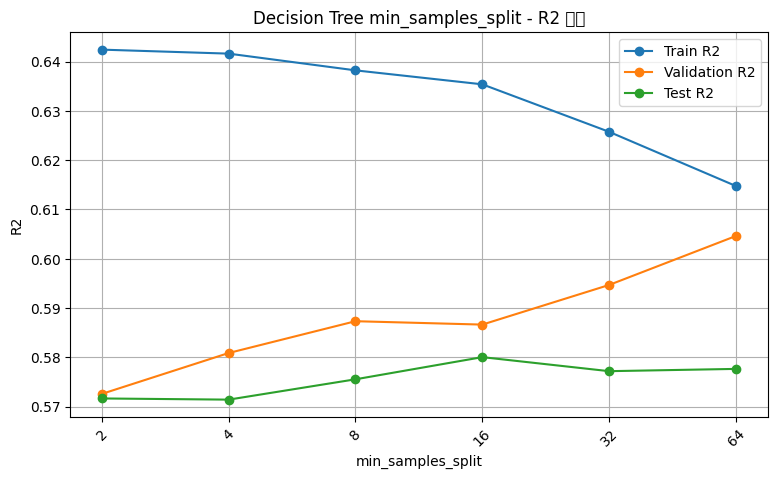

In [17]:
dt_min_samples_split_values = [2, 4, 8, 16, 32, 64]

dt_min_split_result = run_dt_sweep(
    param_name="min_samples_split",
    values=dt_min_samples_split_values,
    base_params={
        "max_depth": 6,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": None,
    },
)

display(dt_min_split_result)
show_best_by_validation(dt_min_split_result, "DT min_samples_split")
plot_hparam_result(
    dt_min_split_result, "min_samples_split", "Decision Tree min_samples_split"
)

,model,changed_param,max_features,max_depth,min_samples_split,min_samples_leaf,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,dt,max_features,None,6,2,1,0.008997,63.817649,69.894712,68.816724,0.642414,0.572611,0.571686
1,dt,max_features,sqrt,6,2,1,0.005093,73.806306,88.273278,80.791064,0.521716,0.318301,0.409661
2,dt,max_features,log2,6,2,1,0.002720,73.806306,88.273278,80.791064,0.521716,0.318301,0.409661
3,dt,max_features,0.3,6,2,1,0.003501,70.101893,81.530489,80.467274,0.568523,0.418467,0.414384
4,dt,max_features,0.5,6,2,1,0.004811,62.649362,73.133159,69.768180,0.655387,0.532089,0.559760
5,dt,max_features,0.7,6,2,1,0.007733,65.737139,71.504564,69.641047,0.620580,0.552697,0.561363
6,dt,max_features,1.0,6,2,1,0.007851,63.817649,69.894712,68.816724,0.642414,0.572611,0.571686


[DT max_features] Validation RMSE 기준 best


,model,changed_param,max_features,max_depth,min_samples_split,min_samples_leaf,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,dt,max_features,None,6,2,1,0.008997,63.817649,69.894712,68.816724,0.642414,0.572611,0.571686


[DT max_features] Validation R2 기준 best


,model,changed_param,max_features,max_depth,min_samples_split,min_samples_leaf,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,dt,max_features,None,6,2,1,0.008997,63.817649,69.894712,68.816724,0.642414,0.572611,0.571686


/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


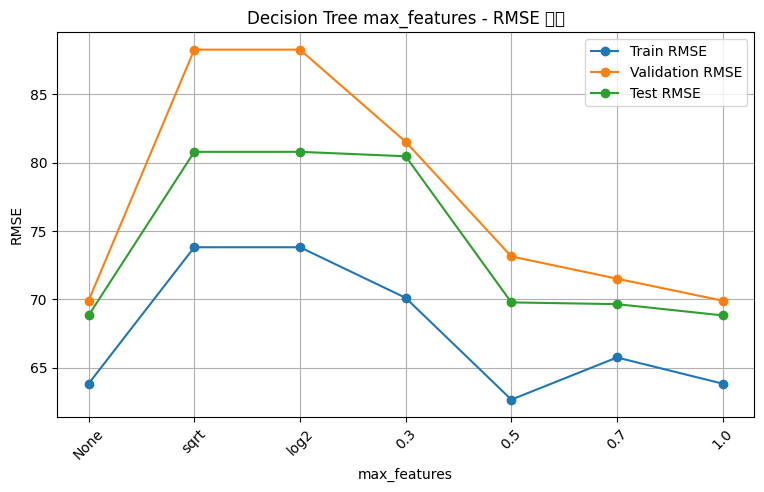

/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


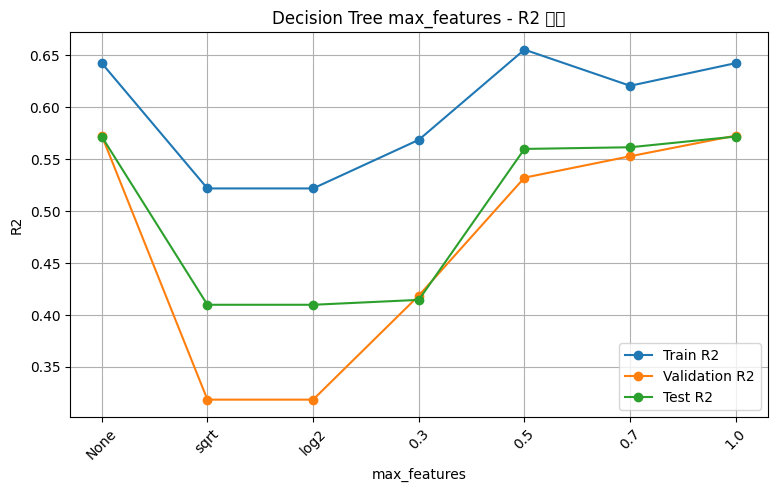

In [18]:
dt_max_features_values = [None, "sqrt", "log2", 0.3, 0.5, 0.7, 1.0]

dt_max_features_result = run_dt_sweep(
    param_name="max_features",
    values=dt_max_features_values,
    base_params={
        "max_depth": 6,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": None,
    },
)

display(dt_max_features_result)
show_best_by_validation(dt_max_features_result, "DT max_features")
plot_hparam_result(dt_max_features_result, "max_features", "Decision Tree max_features")

In [19]:
dt_all_results = pd.concat(
    [
        dt_max_depth_result,
        dt_min_leaf_result,
        dt_min_split_result,
        dt_max_features_result,
    ],
    ignore_index=True,
)

display(dt_all_results)

print("DT 전체 실험 중 Validation RMSE 기준 상위 10개")
display(dt_all_results.sort_values("val_rmse").head(10))

print("DT 전체 실험 중 Validation R2 기준 상위 10개")
display(dt_all_results.sort_values("val_r2", ascending=False).head(10))

,model,changed_param,max_depth,min_samples_split,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,dt,max_depth,2.0,2,1,None,0.004248,83.833119,81.734096,80.529981,0.382937,0.415559,0.413471
1,dt,max_depth,3.0,2,1,None,0.005677,78.944751,78.847378,76.144683,0.452801,0.456113,0.475611
2,dt,max_depth,4.0,2,1,None,0.007160,73.812458,75.639469,73.232517,0.521637,0.499469,0.514954
3,dt,max_depth,5.0,2,1,None,0.007596,68.958211,74.290391,72.501416,0.582487,0.517164,0.524591
4,dt,max_depth,6.0,2,1,None,0.008210,63.817649,69.894712,68.816724,0.642414,0.572611,0.571686
5,dt,max_depth,8.0,2,1,None,0.009748,54.543282,68.816527,73.928159,0.738795,0.585695,0.505696
6,dt,max_depth,10.0,2,1,None,0.012044,44.837875,72.563834,73.666649,0.823482,0.539346,0.509187
7,dt,max_depth,12.0,2,1,None,0.014056,34.138551,80.032773,80.057619,0.897673,0.439636,0.420331
8,dt,max_depth,NaN,2,1,None,0.019818,0.000000,84.470760,84.567193,1.000000,0.375766,0.353187
9,dt,min_samples_leaf,6.0,2,1,None,0.009052,63.817649,69.894712,68.816724,0.642414,0.572611,0.571686


DT 전체 실험 중 Validation RMSE 기준 상위 10개


,model,changed_param,max_depth,min_samples_split,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
20,dt,min_samples_split,6.0,64,1,None,0.008257,66.239639,67.225569,68.333582,0.614757,0.604630,0.577679
19,dt,min_samples_split,6.0,32,1,None,0.008716,65.287875,68.064584,68.370940,0.625748,0.594700,0.577217
13,dt,min_samples_leaf,6.0,2,16,None,0.008208,66.561101,68.068913,68.749369,0.611009,0.594648,0.572524
14,dt,min_samples_leaf,6.0,2,32,None,0.007751,67.607540,68.367168,67.551279,0.598682,0.591088,0.587293
17,dt,min_samples_split,6.0,8,1,None,0.008890,64.191561,68.679133,68.503979,0.638212,0.587348,0.575570
18,dt,min_samples_split,6.0,16,1,None,0.010753,64.442290,68.736221,68.140423,0.635380,0.586662,0.580063
5,dt,max_depth,8.0,2,1,None,0.009748,54.543282,68.816527,73.928159,0.738795,0.585695,0.505696
16,dt,min_samples_split,6.0,4,1,None,0.013246,63.890034,69.213697,68.835912,0.641603,0.580899,0.571447
15,dt,min_samples_split,6.0,2,1,None,0.009682,63.817649,69.894712,68.816724,0.642414,0.572611,0.571686
27,dt,max_features,6.0,2,1,1.0,0.007851,63.817649,69.894712,68.816724,0.642414,0.572611,0.571686


DT 전체 실험 중 Validation R2 기준 상위 10개


,model,changed_param,max_depth,min_samples_split,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
20,dt,min_samples_split,6.0,64,1,None,0.008257,66.239639,67.225569,68.333582,0.614757,0.604630,0.577679
19,dt,min_samples_split,6.0,32,1,None,0.008716,65.287875,68.064584,68.370940,0.625748,0.594700,0.577217
13,dt,min_samples_leaf,6.0,2,16,None,0.008208,66.561101,68.068913,68.749369,0.611009,0.594648,0.572524
14,dt,min_samples_leaf,6.0,2,32,None,0.007751,67.607540,68.367168,67.551279,0.598682,0.591088,0.587293
17,dt,min_samples_split,6.0,8,1,None,0.008890,64.191561,68.679133,68.503979,0.638212,0.587348,0.575570
18,dt,min_samples_split,6.0,16,1,None,0.010753,64.442290,68.736221,68.140423,0.635380,0.586662,0.580063
5,dt,max_depth,8.0,2,1,None,0.009748,54.543282,68.816527,73.928159,0.738795,0.585695,0.505696
16,dt,min_samples_split,6.0,4,1,None,0.013246,63.890034,69.213697,68.835912,0.641603,0.580899,0.571447
15,dt,min_samples_split,6.0,2,1,None,0.009682,63.817649,69.894712,68.816724,0.642414,0.572611,0.571686
4,dt,max_depth,6.0,2,1,None,0.008210,63.817649,69.894712,68.816724,0.642414,0.572611,0.571686


# MLP


In [20]:
def run_mlp_sweep(param_name, values, base_model_params=None, base_train_params=None):
    if base_model_params is None:
        base_model_params = {
            "hidden_dims": [32, 32],
            "dropout": 0.2,
            "activation": nn.ReLU,
            "use_batch_norm": False,
        }

    if base_train_params is None:
        base_train_params = {
            "epochs": 100,
            "lr": 1e-3,
            "batch_size": 64,
            "verbose": False,
        }

    model_param_names = {"hidden_dims", "dropout", "activation", "use_batch_norm"}
    train_param_names = {"epochs", "lr", "batch_size", "verbose"}

    results = []

    for value in values:
        model_params = copy.deepcopy(base_model_params)
        train_params = copy.deepcopy(base_train_params)

        if param_name in model_param_names:
            model_params[param_name] = value
        elif param_name in train_param_names:
            train_params[param_name] = value
        else:
            raise ValueError(f"지원하지 않는 MLP 파라미터입니다: {param_name}")

        set_seed(SEED)

        config = MLPConfig(
            model="mlp",
            input_dim=X_train_mlp.shape[1],
            hidden_dims=model_params["hidden_dims"],
            output_dim=1,
            dropout=model_params["dropout"],
            activation=model_params["activation"],
            use_batch_norm=model_params["use_batch_norm"],
        )

        model = MLP(config)

        train_config = TrainConfig(
            X=X_train_mlp,
            y=y_train,
            epochs=train_params["epochs"],
            lr=train_params["lr"],
            batch_size=train_params["batch_size"],
            verbose=train_params["verbose"],
        )

        start_time = time.time()
        model.fit(train_config)
        elapsed = time.time() - start_time

        row = {
            "model": "mlp",
            "changed_param": param_name,
            param_name: value,
            "hidden_dims": str(model_params["hidden_dims"]),
            "dropout": model_params["dropout"],
            "activation": model_params["activation"].__name__,
            "use_batch_norm": model_params["use_batch_norm"],
            "epochs": train_params["epochs"],
            "lr": train_params["lr"],
            "batch_size": train_params["batch_size"],
            "train_time_sec": elapsed,
        }

        row = add_eval_results(
            row, model, X_train_mlp, y_train, X_val_mlp, y_val, X_test_mlp, y_test
        )

        results.append(row)

    return pd.DataFrame(results)

/home/messae/coding/final_project/house-price-regressor/models/mlp.py:62: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  X = torch.as_tensor(X_train.values, dtype=torch.float32)


,model,changed_param,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,hidden_dims,[16],0.2,ReLU,False,100,0.001,64,7.514564,97.392363,96.895576,94.192915,0.167185,0.178623,0.197563
1,mlp,hidden_dims,[32],0.2,ReLU,False,100,0.001,64,3.479963,88.837125,87.988050,85.150740,0.307073,0.322699,0.344230
2,mlp,hidden_dims,[64],0.2,ReLU,False,100,0.001,64,3.700875,84.515505,83.458952,81.321547,0.372850,0.390631,0.401883
3,mlp,hidden_dims,"[32, 32]",0.2,ReLU,False,100,0.001,64,4.297422,79.619192,79.203371,77.640911,0.443412,0.451190,0.454800
4,mlp,hidden_dims,"[64, 32]",0.2,ReLU,False,100,0.001,64,5.381507,79.148681,78.662600,77.401008,0.449971,0.458659,0.458164
5,mlp,hidden_dims,"[64, 64]",0.2,ReLU,False,100,0.001,64,5.952138,78.024016,78.774188,77.019656,0.465491,0.457122,0.463490
6,mlp,hidden_dims,"[128, 64]",0.2,ReLU,False,100,0.001,64,9.455277,76.720376,78.351733,76.887618,0.483203,0.462929,0.465328
7,mlp,hidden_dims,"[128, 64, 32]",0.2,ReLU,False,100,0.001,64,7.980966,77.274313,78.892206,77.814657,0.475713,0.455494,0.452357


[MLP hidden_dims] Validation RMSE 기준 best


,model,changed_param,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
6,mlp,hidden_dims,"[128, 64]",0.2,ReLU,False,100,0.001,64,9.455277,76.720376,78.351733,76.887618,0.483203,0.462929,0.465328


[MLP hidden_dims] Validation R2 기준 best


,model,changed_param,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
6,mlp,hidden_dims,"[128, 64]",0.2,ReLU,False,100,0.001,64,9.455277,76.720376,78.351733,76.887618,0.483203,0.462929,0.465328


/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


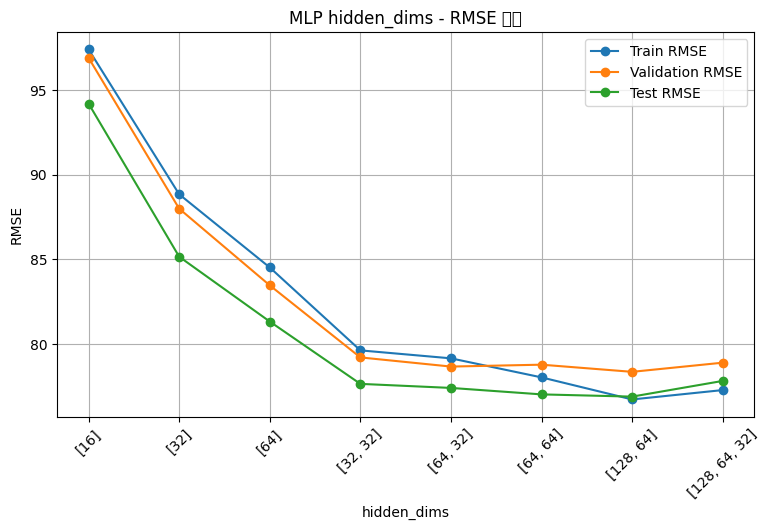

/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


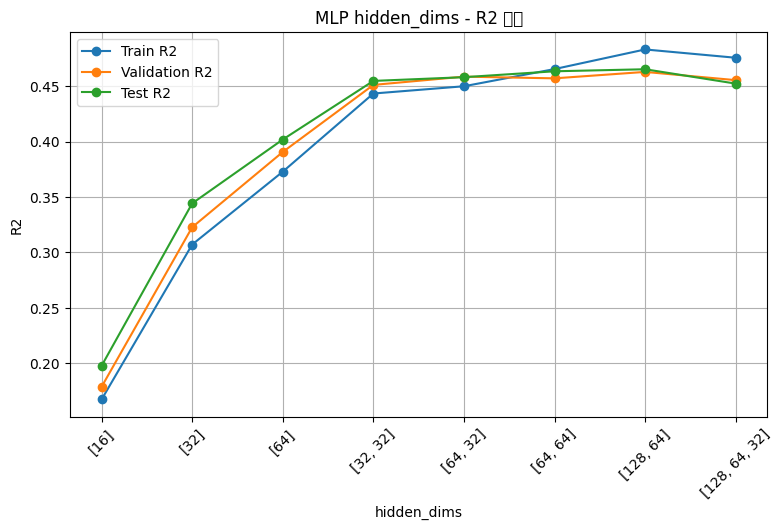

In [21]:
mlp_hidden_dims_values = [
    [16],
    [32],
    [64],
    [32, 32],
    [64, 32],
    [64, 64],
    [128, 64],
    [128, 64, 32],
]

mlp_hidden_result = run_mlp_sweep(
    param_name="hidden_dims",
    values=mlp_hidden_dims_values,
    base_model_params={
        "hidden_dims": [32, 32],
        "dropout": 0.2,
        "activation": nn.ReLU,
        "use_batch_norm": False,
    },
    base_train_params={"epochs": 100, "lr": 1e-3, "batch_size": 64, "verbose": False},
)

display(mlp_hidden_result)
show_best_by_validation(mlp_hidden_result, "MLP hidden_dims")
plot_hparam_result(mlp_hidden_result, "hidden_dims", "MLP hidden_dims")

,model,changed_param,dropout,hidden_dims,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,dropout,0.0,"[32, 32]",ReLU,False,100,0.001,64,3.725633,78.921648,79.779717,77.998733,0.453122,0.443174,0.449763
1,mlp,dropout,0.1,"[32, 32]",ReLU,False,100,0.001,64,4.343321,79.189986,79.232690,77.594629,0.449396,0.450784,0.455450
2,mlp,dropout,0.2,"[32, 32]",ReLU,False,100,0.001,64,4.219890,79.619192,79.203371,77.640911,0.443412,0.451190,0.454800
3,mlp,dropout,0.3,"[32, 32]",ReLU,False,100,0.001,64,4.144533,80.185496,79.163733,77.888681,0.435466,0.451740,0.451315
4,mlp,dropout,0.5,"[32, 32]",ReLU,False,100,0.001,64,4.223853,82.657302,80.438404,79.489849,0.400125,0.433942,0.428524


[MLP dropout] Validation RMSE 기준 best


,model,changed_param,dropout,hidden_dims,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
3,mlp,dropout,0.3,"[32, 32]",ReLU,False,100,0.001,64,4.144533,80.185496,79.163733,77.888681,0.435466,0.45174,0.451315


[MLP dropout] Validation R2 기준 best


,model,changed_param,dropout,hidden_dims,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
3,mlp,dropout,0.3,"[32, 32]",ReLU,False,100,0.001,64,4.144533,80.185496,79.163733,77.888681,0.435466,0.45174,0.451315


/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


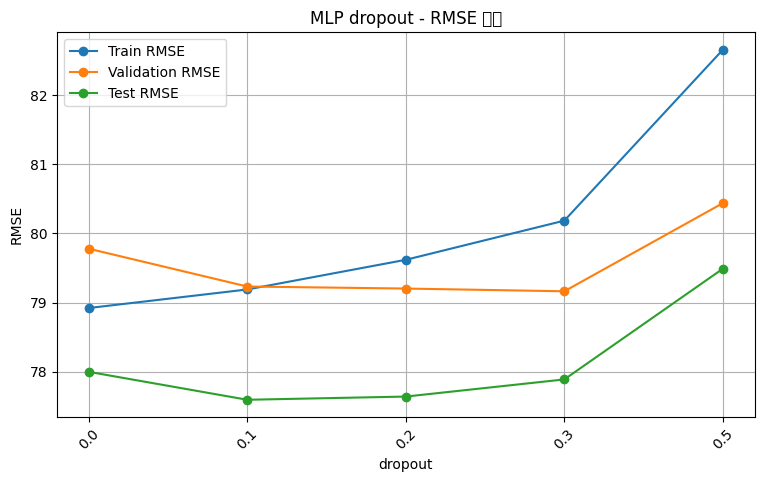

/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


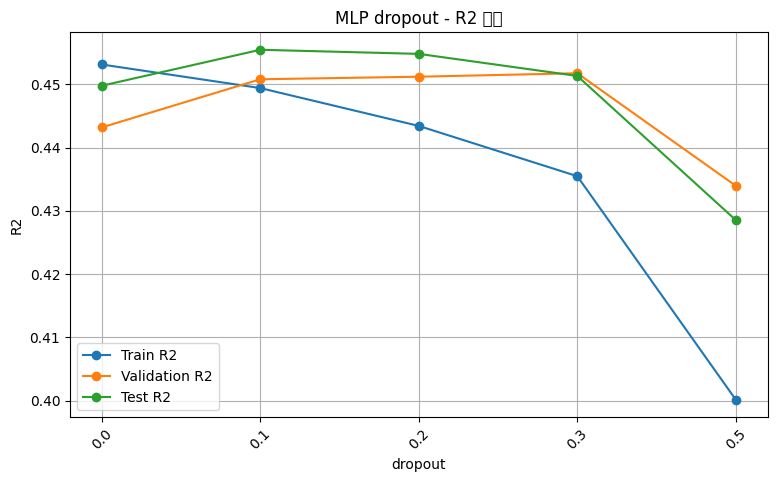

In [22]:
mlp_dropout_values = [0.0, 0.1, 0.2, 0.3, 0.5]

mlp_dropout_result = run_mlp_sweep(
    param_name="dropout",
    values=mlp_dropout_values,
    base_model_params={
        "hidden_dims": [32, 32],
        "dropout": 0.2,
        "activation": nn.ReLU,
        "use_batch_norm": False,
    },
    base_train_params={"epochs": 100, "lr": 1e-3, "batch_size": 64, "verbose": False},
)

display(mlp_dropout_result)
show_best_by_validation(mlp_dropout_result, "MLP dropout")
plot_hparam_result(mlp_dropout_result, "dropout", "MLP dropout")

,model,changed_param,lr,hidden_dims,dropout,activation,use_batch_norm,epochs,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,lr,0.0001,"[32, 32]",0.2,ReLU,False,100,64,7.104701,115.170533,116.492516,112.644198,-0.164612,-0.187218,-0.147605
1,mlp,lr,0.0003,"[32, 32]",0.2,ReLU,False,100,64,4.590566,86.015270,85.071420,82.768751,0.350395,0.366857,0.380406
2,mlp,lr,0.0010,"[32, 32]",0.2,ReLU,False,100,64,4.285673,79.619192,79.203371,77.640911,0.443412,0.451190,0.454800
3,mlp,lr,0.0030,"[32, 32]",0.2,ReLU,False,100,64,4.138456,77.755153,78.244381,76.724072,0.469168,0.464400,0.467600
4,mlp,lr,0.0100,"[32, 32]",0.2,ReLU,False,100,64,4.199043,78.231094,77.997451,76.983063,0.462650,0.467775,0.464000


[MLP learning rate] Validation RMSE 기준 best


,model,changed_param,lr,hidden_dims,dropout,activation,use_batch_norm,epochs,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
4,mlp,lr,0.01,"[32, 32]",0.2,ReLU,False,100,64,4.199043,78.231094,77.997451,76.983063,0.46265,0.467775,0.464


[MLP learning rate] Validation R2 기준 best


,model,changed_param,lr,hidden_dims,dropout,activation,use_batch_norm,epochs,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
4,mlp,lr,0.01,"[32, 32]",0.2,ReLU,False,100,64,4.199043,78.231094,77.997451,76.983063,0.46265,0.467775,0.464


/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


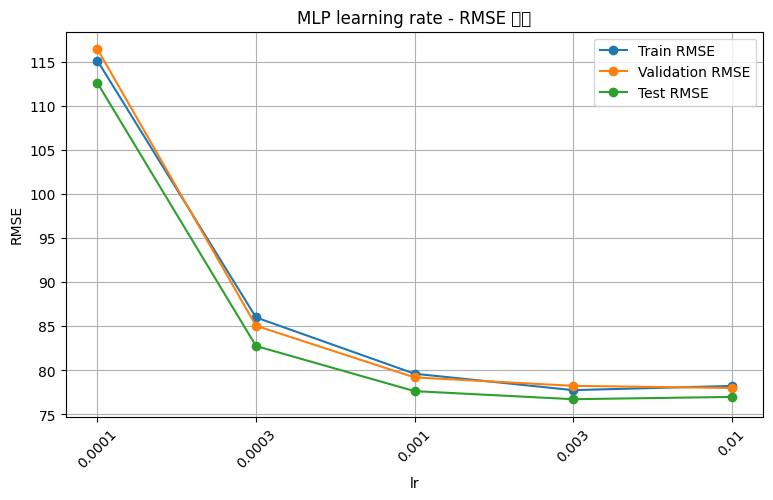

/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


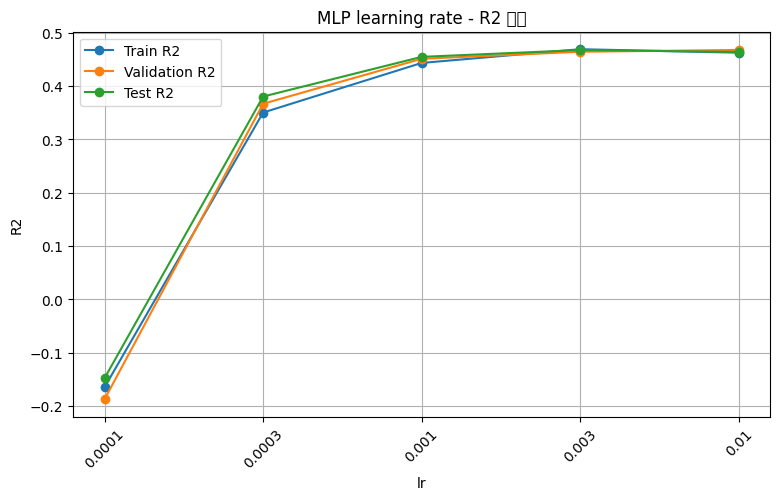

In [23]:
mlp_lr_values = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

mlp_lr_result = run_mlp_sweep(
    param_name="lr",
    values=mlp_lr_values,
    base_model_params={
        "hidden_dims": [32, 32],
        "dropout": 0.2,
        "activation": nn.ReLU,
        "use_batch_norm": False,
    },
    base_train_params={"epochs": 100, "lr": 1e-3, "batch_size": 64, "verbose": False},
)

display(mlp_lr_result)
show_best_by_validation(mlp_lr_result, "MLP learning rate")
plot_hparam_result(mlp_lr_result, "lr", "MLP learning rate")

,model,changed_param,batch_size,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,batch_size,16.0,"[32, 32]",0.2,ReLU,False,100,0.001,15.888694,78.445674,77.992347,76.905638,0.459698,0.467845,0.465077
1,mlp,batch_size,32.0,"[32, 32]",0.2,ReLU,False,100,0.001,7.490768,78.860323,78.466066,76.879090,0.453971,0.461361,0.465447
2,mlp,batch_size,64.0,"[32, 32]",0.2,ReLU,False,100,0.001,4.211478,79.619192,79.203371,77.640911,0.443412,0.451190,0.454800
3,mlp,batch_size,128.0,"[32, 32]",0.2,ReLU,False,100,0.001,6.515695,81.732113,81.097712,79.351011,0.413478,0.424624,0.430519
4,mlp,batch_size,256.0,"[32, 32]",0.2,ReLU,False,100,0.001,2.917803,86.278897,85.618036,83.245452,0.346407,0.358695,0.373248
5,mlp,batch_size,NaN,"[32, 32]",0.2,ReLU,False,100,0.001,1.703644,273.259954,269.151284,272.030205,-5.556175,-5.337636,-5.692816


[MLP batch_size] Validation RMSE 기준 best


,model,changed_param,batch_size,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,batch_size,16.0,"[32, 32]",0.2,ReLU,False,100,0.001,15.888694,78.445674,77.992347,76.905638,0.459698,0.467845,0.465077


[MLP batch_size] Validation R2 기준 best


,model,changed_param,batch_size,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,batch_size,16.0,"[32, 32]",0.2,ReLU,False,100,0.001,15.888694,78.445674,77.992347,76.905638,0.459698,0.467845,0.465077


/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


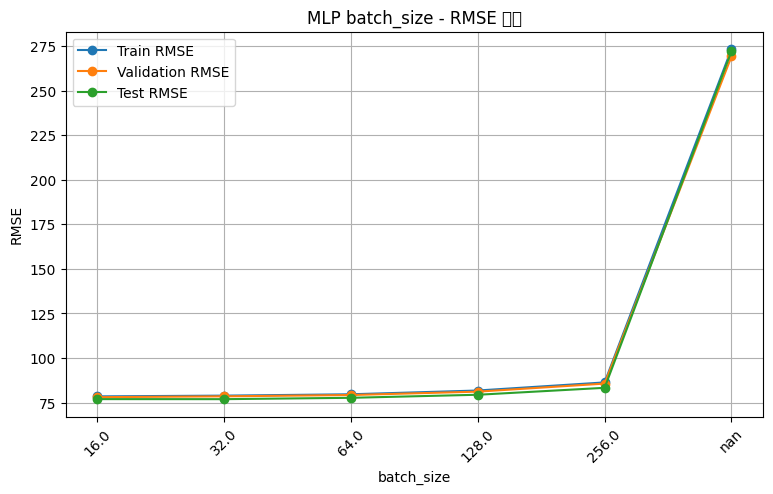

/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


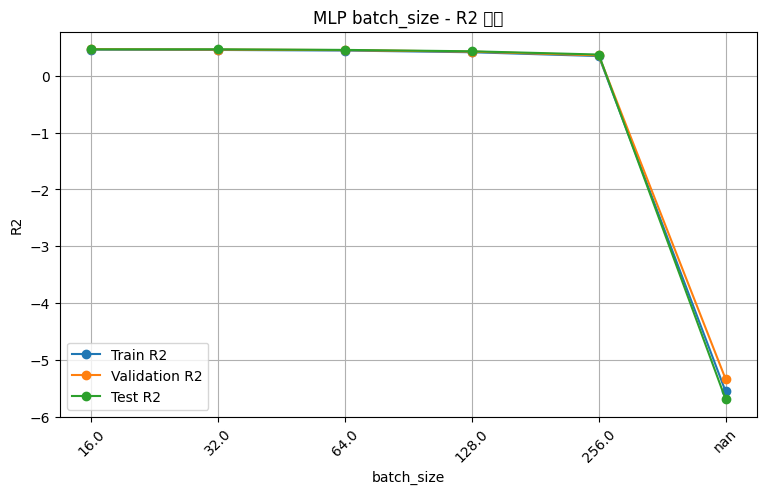

In [24]:
mlp_batch_size_values = [16, 32, 64, 128, 256, None]

mlp_batch_result = run_mlp_sweep(
    param_name="batch_size",
    values=mlp_batch_size_values,
    base_model_params={
        "hidden_dims": [32, 32],
        "dropout": 0.2,
        "activation": nn.ReLU,
        "use_batch_norm": False,
    },
    base_train_params={"epochs": 100, "lr": 1e-3, "batch_size": 64, "verbose": False},
)

display(mlp_batch_result)
show_best_by_validation(mlp_batch_result, "MLP batch_size")
plot_hparam_result(mlp_batch_result, "batch_size", "MLP batch_size")

,model,changed_param,epochs,hidden_dims,dropout,activation,use_batch_norm,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,epochs,10,"[32, 32]",0.2,ReLU,False,0.001,64,0.437481,110.723124,111.562673,107.982746,-0.076404,-0.088860,-0.054589
1,mlp,epochs,30,"[32, 32]",0.2,ReLU,False,0.001,64,1.269406,86.119079,85.310483,82.997813,0.348826,0.363294,0.376971
2,mlp,epochs,50,"[32, 32]",0.2,ReLU,False,0.001,64,2.074802,82.478560,81.746310,80.053470,0.402716,0.415384,0.420391
3,mlp,epochs,100,"[32, 32]",0.2,ReLU,False,0.001,64,4.291945,79.619192,79.203371,77.640911,0.443412,0.451190,0.454800
4,mlp,epochs,150,"[32, 32]",0.2,ReLU,False,0.001,64,9.233060,78.530286,78.492273,76.862666,0.458532,0.461001,0.465675
5,mlp,epochs,200,"[32, 32]",0.2,ReLU,False,0.001,64,8.837143,77.894429,77.948934,76.631576,0.467265,0.468437,0.468883


[MLP epochs] Validation RMSE 기준 best


,model,changed_param,epochs,hidden_dims,dropout,activation,use_batch_norm,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
5,mlp,epochs,200,"[32, 32]",0.2,ReLU,False,0.001,64,8.837143,77.894429,77.948934,76.631576,0.467265,0.468437,0.468883


[MLP epochs] Validation R2 기준 best


,model,changed_param,epochs,hidden_dims,dropout,activation,use_batch_norm,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
5,mlp,epochs,200,"[32, 32]",0.2,ReLU,False,0.001,64,8.837143,77.894429,77.948934,76.631576,0.467265,0.468437,0.468883


/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


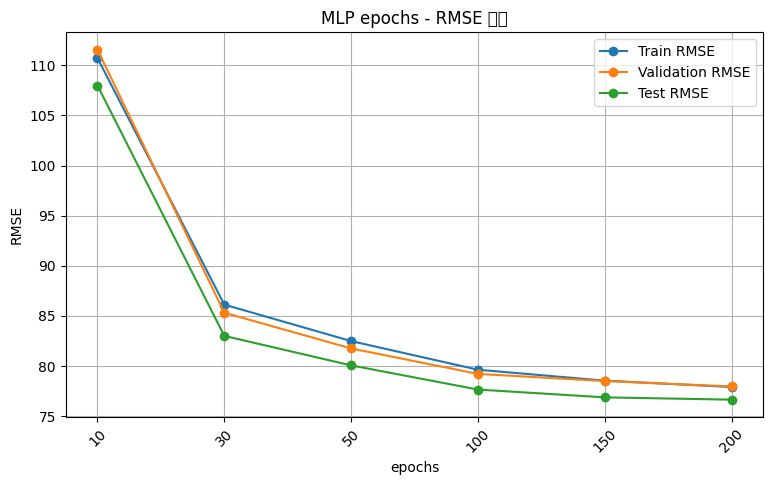

/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


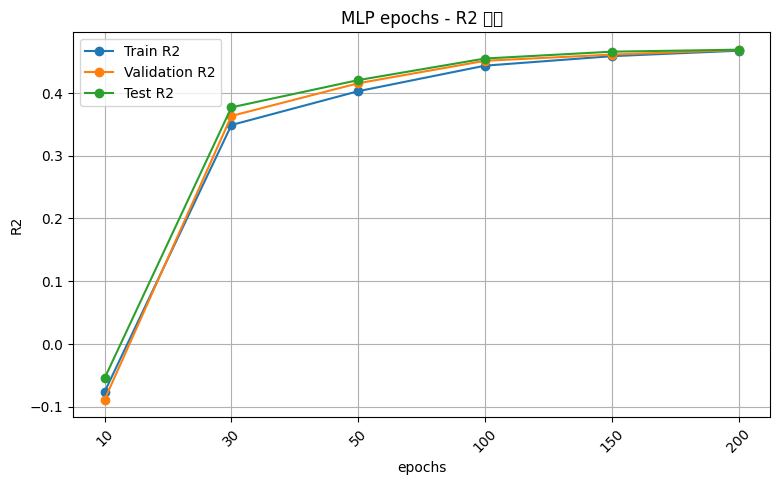

In [25]:
mlp_epochs_values = [10, 30, 50, 100, 150, 200]

mlp_epochs_result = run_mlp_sweep(
    param_name="epochs",
    values=mlp_epochs_values,
    base_model_params={
        "hidden_dims": [32, 32],
        "dropout": 0.2,
        "activation": nn.ReLU,
        "use_batch_norm": False,
    },
    base_train_params={"epochs": 100, "lr": 1e-3, "batch_size": 64, "verbose": False},
)

display(mlp_epochs_result)
show_best_by_validation(mlp_epochs_result, "MLP epochs")
plot_hparam_result(mlp_epochs_result, "epochs", "MLP epochs")

,model,changed_param,activation,hidden_dims,dropout,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,activation,ReLU,"[32, 32]",0.2,False,100,0.001,64,4.470709,79.619192,79.203371,77.640911,0.443412,0.451190,0.454800
1,mlp,activation,Tanh,"[32, 32]",0.2,False,100,0.001,64,4.175842,173.899141,170.241928,172.080080,-1.655177,-1.535522,-1.678156
2,mlp,activation,LeakyReLU,"[32, 32]",0.2,False,100,0.001,64,4.392659,79.751187,79.257059,77.661736,0.441565,0.450446,0.454507
3,mlp,activation,ELU,"[32, 32]",0.2,False,100,0.001,64,7.049788,70.551961,69.657984,68.443760,0.562965,0.575501,0.576316


[MLP activation] Validation RMSE 기준 best


,model,changed_param,activation,hidden_dims,dropout,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
3,mlp,activation,ELU,"[32, 32]",0.2,False,100,0.001,64,7.049788,70.551961,69.657984,68.44376,0.562965,0.575501,0.576316


[MLP activation] Validation R2 기준 best


,model,changed_param,activation,hidden_dims,dropout,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
3,mlp,activation,ELU,"[32, 32]",0.2,False,100,0.001,64,7.049788,70.551961,69.657984,68.44376,0.562965,0.575501,0.576316


/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


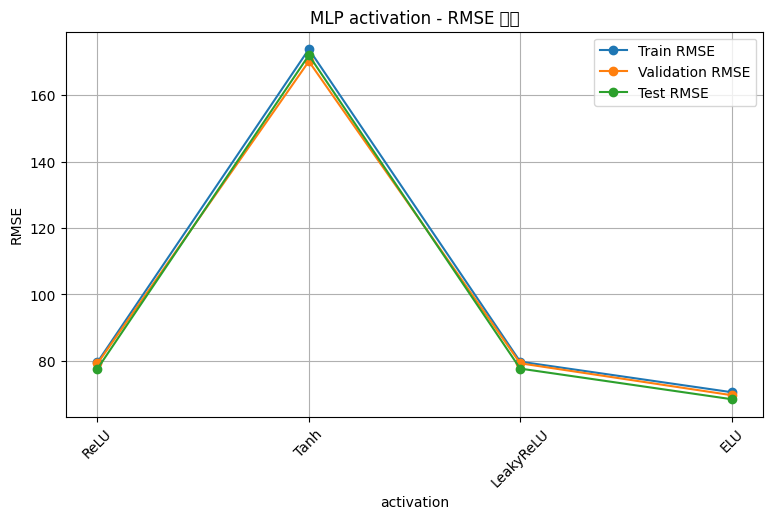

/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


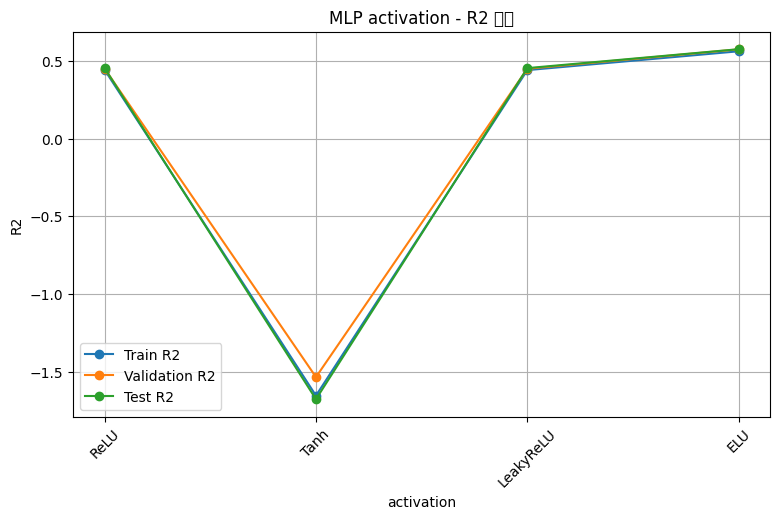

In [26]:
mlp_activation_values = [nn.ReLU, nn.Tanh, nn.LeakyReLU, nn.ELU]

mlp_activation_result = run_mlp_sweep(
    param_name="activation",
    values=mlp_activation_values,
    base_model_params={
        "hidden_dims": [32, 32],
        "dropout": 0.2,
        "activation": nn.ReLU,
        "use_batch_norm": False,
    },
    base_train_params={"epochs": 100, "lr": 1e-3, "batch_size": 64, "verbose": False},
)

display(mlp_activation_result)
show_best_by_validation(mlp_activation_result, "MLP activation")
plot_hparam_result(mlp_activation_result, "activation", "MLP activation")

In [27]:
mlp_all_results = pd.concat(
    [
        mlp_hidden_result,
        mlp_dropout_result,
        mlp_lr_result,
        mlp_batch_result,
        mlp_epochs_result,
        mlp_activation_result,
    ],
    ignore_index=True,
)

display(mlp_all_results)

print("MLP 전체 실험 중 Validation RMSE 기준 상위 10개")
display(mlp_all_results.sort_values("val_rmse").head(10))

print("MLP 전체 실험 중 Validation R2 기준 상위 10개")
display(mlp_all_results.sort_values("val_r2", ascending=False).head(10))

,model,changed_param,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,hidden_dims,[16],0.2,ReLU,False,100,0.0010,64.0,7.514564,97.392363,96.895576,94.192915,0.167185,0.178623,0.197563
1,mlp,hidden_dims,[32],0.2,ReLU,False,100,0.0010,64.0,3.479963,88.837125,87.988050,85.150740,0.307073,0.322699,0.344230
2,mlp,hidden_dims,[64],0.2,ReLU,False,100,0.0010,64.0,3.700875,84.515505,83.458952,81.321547,0.372850,0.390631,0.401883
3,mlp,hidden_dims,"[32, 32]",0.2,ReLU,False,100,0.0010,64.0,4.297422,79.619192,79.203371,77.640911,0.443412,0.451190,0.454800
4,mlp,hidden_dims,"[64, 32]",0.2,ReLU,False,100,0.0010,64.0,5.381507,79.148681,78.662600,77.401008,0.449971,0.458659,0.458164
5,mlp,hidden_dims,"[64, 64]",0.2,ReLU,False,100,0.0010,64.0,5.952138,78.024016,78.774188,77.019656,0.465491,0.457122,0.463490
6,mlp,hidden_dims,"[128, 64]",0.2,ReLU,False,100,0.0010,64.0,9.455277,76.720376,78.351733,76.887618,0.483203,0.462929,0.465328
7,mlp,hidden_dims,"[128, 64, 32]",0.2,ReLU,False,100,0.0010,64.0,7.980966,77.274313,78.892206,77.814657,0.475713,0.455494,0.452357
8,mlp,dropout,"[32, 32]",0.0,ReLU,False,100,0.0010,64.0,3.725633,78.921648,79.779717,77.998733,0.453122,0.443174,0.449763
9,mlp,dropout,"[32, 32]",0.1,ReLU,False,100,0.0010,64.0,4.343321,79.189986,79.232690,77.594629,0.449396,0.450784,0.455450


MLP 전체 실험 중 Validation RMSE 기준 상위 10개


,model,changed_param,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
33,mlp,activation,"[32, 32]",0.2,ELU,False,100,0.001,64.0,7.049788,70.551961,69.657984,68.443760,0.562965,0.575501,0.576316
29,mlp,epochs,"[32, 32]",0.2,ReLU,False,200,0.001,64.0,8.837143,77.894429,77.948934,76.631576,0.467265,0.468437,0.468883
18,mlp,batch_size,"[32, 32]",0.2,ReLU,False,100,0.001,16.0,15.888694,78.445674,77.992347,76.905638,0.459698,0.467845,0.465077
17,mlp,lr,"[32, 32]",0.2,ReLU,False,100,0.010,64.0,4.199043,78.231094,77.997451,76.983063,0.462650,0.467775,0.464000
16,mlp,lr,"[32, 32]",0.2,ReLU,False,100,0.003,64.0,4.138456,77.755153,78.244381,76.724072,0.469168,0.464400,0.467600
6,mlp,hidden_dims,"[128, 64]",0.2,ReLU,False,100,0.001,64.0,9.455277,76.720376,78.351733,76.887618,0.483203,0.462929,0.465328
19,mlp,batch_size,"[32, 32]",0.2,ReLU,False,100,0.001,32.0,7.490768,78.860323,78.466066,76.879090,0.453971,0.461361,0.465447
28,mlp,epochs,"[32, 32]",0.2,ReLU,False,150,0.001,64.0,9.233060,78.530286,78.492273,76.862666,0.458532,0.461001,0.465675
4,mlp,hidden_dims,"[64, 32]",0.2,ReLU,False,100,0.001,64.0,5.381507,79.148681,78.662600,77.401008,0.449971,0.458659,0.458164
5,mlp,hidden_dims,"[64, 64]",0.2,ReLU,False,100,0.001,64.0,5.952138,78.024016,78.774188,77.019656,0.465491,0.457122,0.463490


MLP 전체 실험 중 Validation R2 기준 상위 10개


,model,changed_param,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
33,mlp,activation,"[32, 32]",0.2,ELU,False,100,0.001,64.0,7.049788,70.551961,69.657984,68.443760,0.562965,0.575501,0.576316
29,mlp,epochs,"[32, 32]",0.2,ReLU,False,200,0.001,64.0,8.837143,77.894429,77.948934,76.631576,0.467265,0.468437,0.468883
18,mlp,batch_size,"[32, 32]",0.2,ReLU,False,100,0.001,16.0,15.888694,78.445674,77.992347,76.905638,0.459698,0.467845,0.465077
17,mlp,lr,"[32, 32]",0.2,ReLU,False,100,0.010,64.0,4.199043,78.231094,77.997451,76.983063,0.462650,0.467775,0.464000
16,mlp,lr,"[32, 32]",0.2,ReLU,False,100,0.003,64.0,4.138456,77.755153,78.244381,76.724072,0.469168,0.464400,0.467600
6,mlp,hidden_dims,"[128, 64]",0.2,ReLU,False,100,0.001,64.0,9.455277,76.720376,78.351733,76.887618,0.483203,0.462929,0.465328
19,mlp,batch_size,"[32, 32]",0.2,ReLU,False,100,0.001,32.0,7.490768,78.860323,78.466066,76.879090,0.453971,0.461361,0.465447
28,mlp,epochs,"[32, 32]",0.2,ReLU,False,150,0.001,64.0,9.233060,78.530286,78.492273,76.862666,0.458532,0.461001,0.465675
4,mlp,hidden_dims,"[64, 32]",0.2,ReLU,False,100,0.001,64.0,5.381507,79.148681,78.662600,77.401008,0.449971,0.458659,0.458164
5,mlp,hidden_dims,"[64, 64]",0.2,ReLU,False,100,0.001,64.0,5.952138,78.024016,78.774188,77.019656,0.465491,0.457122,0.463490


DT vs MLP 최종 비교 그래프


In [28]:
best_dt = dt_all_results.loc[dt_all_results["val_rmse"].idxmin()].copy()
best_mlp = mlp_all_results.loc[mlp_all_results["val_rmse"].idxmin()].copy()

comparison_df = pd.DataFrame(
    [
        {
            "model": "Decision Tree",
            "best_changed_param": best_dt["changed_param"],
            "val_rmse": best_dt["val_rmse"],
            "test_rmse": best_dt["test_rmse"],
            "val_r2": best_dt["val_r2"],
            "test_r2": best_dt["test_r2"],
        },
        {
            "model": "MLP",
            "best_changed_param": best_mlp["changed_param"],
            "val_rmse": best_mlp["val_rmse"],
            "test_rmse": best_mlp["test_rmse"],
            "val_r2": best_mlp["val_r2"],
            "test_r2": best_mlp["test_r2"],
        },
    ]
)

display(comparison_df)

,model,best_changed_param,val_rmse,test_rmse,val_r2,test_r2
0,Decision Tree,min_samples_split,67.225569,68.333582,0.604630,0.577679
1,MLP,activation,69.657984,68.443760,0.575501,0.576316


/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/messae/anaconda3/envs/cse402/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


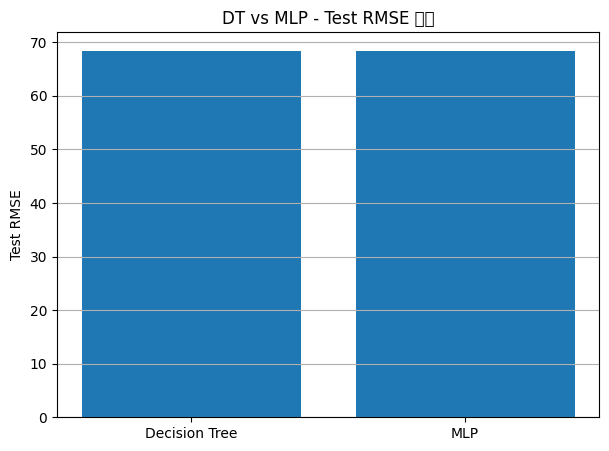

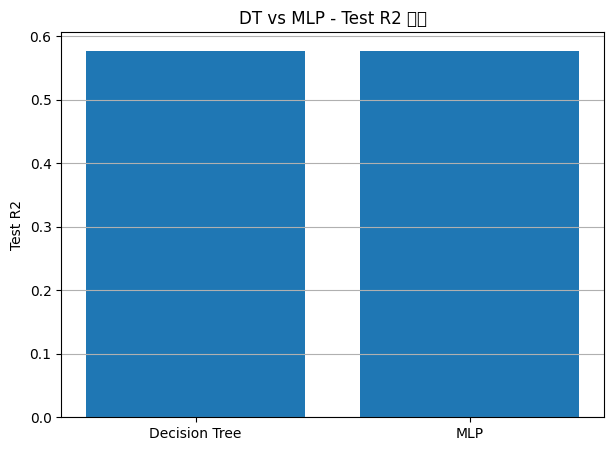

In [29]:
# RMSE 비교
plt.figure(figsize=(7, 5))
plt.bar(comparison_df["model"], comparison_df["test_rmse"])
plt.ylabel("Test RMSE")
plt.title("DT vs MLP - Test RMSE 비교")
plt.grid(axis="y")
plt.show()

# R2 비교
plt.figure(figsize=(7, 5))
plt.bar(comparison_df["model"], comparison_df["test_r2"])
plt.ylabel("Test R2")
plt.title("DT vs MLP - Test R2 비교")
plt.grid(axis="y")
plt.show()